### ==============================================================================
## Overview Map: Western Mediterranean - CTD & MVP Trajectories
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from FaSt-SWOT & BioSWOT-MED experiments
# 
**DESCRIPTION**:
 This script generates a comprehensive map of the Western Mediterranean showing:
   - CTD station positions from FaSt-SWOT (Leg1 + Leg2) and BioSWOT-MED campaigns
   - MVP (Moving Vessel Profiler) trajectories from both experiments
#
### ==============================================================================

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import re
import io
import warnings

# Cartopy for professional maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

warnings.filterwarnings("ignore")

# ==========================================
# 1. DATA PATHS
# ==========================================

# FaSt-SWOT
BASE_FASTSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")
DIR_MVP_FASTSWOT_LEG1 = BASE_FASTSWOT / "Data" / "Leg1" / "processed_step1_highres_qc"
DIR_MVP_FASTSWOT_LEG2 = BASE_FASTSWOT / "Data" / "Leg2" / "processed_step1_highres_qc"
DIR_CTD_FASTSWOT_LEG1 = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/CTD/CTD_data/leg1/HM/")
DIR_CTD_FASTSWOT_LEG2 = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/CTD/CTD_data/leg2/HM/")

# BioSWOT-MED
BASE_BIOSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing")
DIR_MVP_BIOSWOT = BASE_BIOSWOT / "Data" / "processed_step1_highres_qc"
DIR_CTD_BIOSWOT = Path(r"C:\Users\ASUS\Desktop\BioSWOT_data\CTD\cnv")

# Output
OUTDIR = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\Figures_overview")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Paths configured.")

Paths configured.


In [6]:
# ==========================================
# 2. FUNCTIONS TO LOAD DATA
# ==========================================

def read_ctd_positions(ctd_dir, pattern="d*.cnv"):
    """
    Reads CTD .cnv files and extracts lat/lon positions.
    Returns a DataFrame with lat, lon, time, and filename.
    """
    data = []
    files = sorted(list(ctd_dir.glob(pattern)))
    if not files:
        files = sorted(list(ctd_dir.glob("*.cnv")))
    
    for path in files:
        try:
            with open(path, 'r', encoding='latin-1') as f:
                lines = f.readlines()
            
            lat, lon, time_val = np.nan, np.nan, pd.NaT
            
            for line in lines[:60]:
                if 'NMEA Latitude' in line:
                    parts = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                    if len(parts) >= 2:
                        lat = float(parts[0]) + float(parts[1])/60 * (-1 if 'S' in line else 1)
                if 'NMEA Longitude' in line:
                    parts = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                    if len(parts) >= 2:
                        lon = float(parts[0]) + float(parts[1])/60 * (-1 if 'W' in line else 1)
                if 'start_time' in line:
                    try:
                        time_val = pd.to_datetime(line.split('=')[1].strip().split('[')[0])
                    except:
                        pass
                if '*END*' in line:
                    break
            
            if not np.isnan(lat) and not np.isnan(lon):
                data.append({'lat': lat, 'lon': lon, 'time': time_val, 'file': path.name})
        except Exception as e:
            print(f"Error reading {path.name}: {e}")
    
    return pd.DataFrame(data)


def load_mvp_positions(mvp_dir):
    """
    Loads MVP positions from NetCDF files.
    Returns a DataFrame sorted by time.
    """
    data = []
    files = sorted(list(mvp_dir.glob("*.nc")))
    
    for f in files:
        try:
            with xr.open_dataset(f) as ds:
                # Try different variable names for lat/lon
                if 'lat' in ds:
                    lat = np.nanmean(ds['lat'].values)
                elif 'latitude' in ds:
                    lat = np.nanmean(ds['latitude'].values)
                else:
                    lat = np.nan
                
                if 'lon' in ds:
                    lon = np.nanmean(ds['lon'].values)
                elif 'longitude' in ds:
                    lon = np.nanmean(ds['longitude'].values)
                else:
                    lon = np.nan
                
                # Get time
                t_val = pd.NaT
                if 'time' in ds:
                    ts = ds.time.values
                    if ts.size > 0:
                        t_val = pd.to_datetime(np.ravel(ts)[0])
                elif 'start_time' in ds.attrs:
                    t_val = pd.to_datetime(ds.attrs['start_time'])
                
                if not np.isnan(lat) and not np.isnan(lon):
                    data.append({'lat': lat, 'lon': lon, 'time': t_val, 'file': f.name})
        except Exception as e:
            pass
    
    df = pd.DataFrame(data)
    if not df.empty and 'time' in df.columns:
        df = df.sort_values('time').reset_index(drop=True)
    return df

print("Functions defined.")

Functions defined.


In [7]:
# ==========================================
# 3. LOAD ALL DATA
# ==========================================

print("Loading CTD positions...")

# FaSt-SWOT CTDs
ctd_fastswot_leg1 = read_ctd_positions(DIR_CTD_FASTSWOT_LEG1)
ctd_fastswot_leg2 = read_ctd_positions(DIR_CTD_FASTSWOT_LEG2)
print(f"  FaSt-SWOT Leg1: {len(ctd_fastswot_leg1)} CTD stations")
print(f"  FaSt-SWOT Leg2: {len(ctd_fastswot_leg2)} CTD stations")

# BioSWOT CTDs
ctd_bioswot = read_ctd_positions(DIR_CTD_BIOSWOT, pattern="*.cnv")
print(f"  BioSWOT-MED: {len(ctd_bioswot)} CTD stations")

print("\nLoading MVP trajectories...")

# FaSt-SWOT MVPs
mvp_fastswot_leg1 = load_mvp_positions(DIR_MVP_FASTSWOT_LEG1)
mvp_fastswot_leg2 = load_mvp_positions(DIR_MVP_FASTSWOT_LEG2)
print(f"  FaSt-SWOT Leg1: {len(mvp_fastswot_leg1)} MVP profiles")
print(f"  FaSt-SWOT Leg2: {len(mvp_fastswot_leg2)} MVP profiles")

# BioSWOT MVPs
mvp_bioswot = load_mvp_positions(DIR_MVP_BIOSWOT)
print(f"  BioSWOT-MED: {len(mvp_bioswot)} MVP profiles")

print("\nData loaded successfully!")

Loading CTD positions...
  FaSt-SWOT Leg1: 12 CTD stations
  FaSt-SWOT Leg2: 10 CTD stations
  BioSWOT-MED: 48 CTD stations

Loading MVP trajectories...
  FaSt-SWOT Leg1: 591 MVP profiles
  FaSt-SWOT Leg2: 297 MVP profiles
  BioSWOT-MED: 629 MVP profiles

Data loaded successfully!


Figure saved: C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\Figures_overview\Western_Med_Overview_CTD_MVP_SELECTED_publication.png


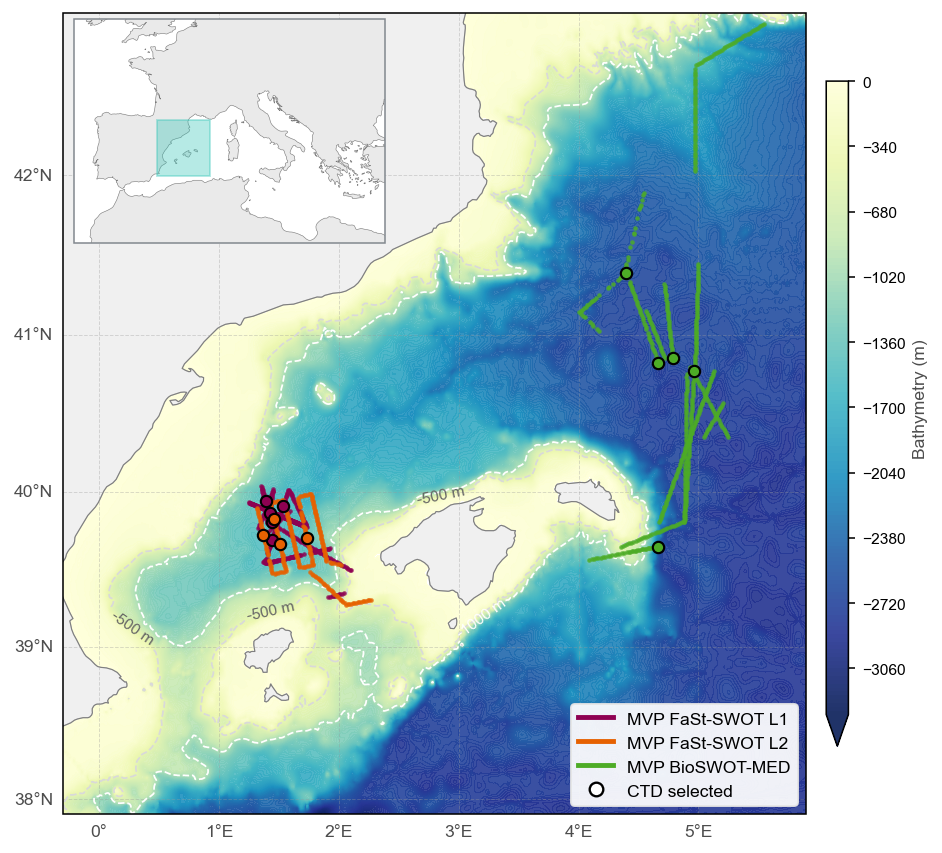

In [4]:
# ==========================================
# FINAL MAP FOR PUBLICATION: MVP + SELECTED CTDs
# ==========================================

from matplotlib.lines import Line2D

# Files with CTD stations used in RMSD analysis
rmsd_leg1 = pd.read_csv(Path(r"C:/Users/ASUS/Desktop/mvp_paper/codes_paper_publish/RESULTS/RMSD_Reduction_Leg1.csv"))
rmsd_leg2 = pd.read_csv(Path(r"C:/Users/ASUS/Desktop/mvp_paper/codes_paper_publish/RESULTS/RMSD_Reduction_Leg2.csv"))
rmsd_bioswot = pd.read_csv(Path(r"C:/Users/ASUS/Desktop/mvp_paper/codes_paper_publish/RESULTS/RMSD_Reduction_BioSWOT.csv"))

# Set with selected CTD station names
ctd_used_names = set(rmsd_leg1["CTD_Station"]).union(
    rmsd_leg2["CTD_Station"],
    rmsd_bioswot["CTD_Station"],
)

# Publication style (clean and readable)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["axes.linewidth"] = 0.8

# Campaign colors (colorblind-friendly)
COLOR_FASTSWOT_LEG1 = "#8E0152"
COLOR_FASTSWOT_LEG2 = "#E66101"
COLOR_BIOSWOT = "#4DAC26"

# --------------------------------------------------
# 1) Bathymetry loading
# --------------------------------------------------
bathy_loaded = False
LON_MIN_BATHY, LON_MAX_BATHY = -0.5, 6.5
LAT_MIN_BATHY, LAT_MAX_BATHY = 38.0, 43.3

try:
    from netCDF4 import Dataset as netCDF_Dataset

    dir_topo = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/OSSEs/topography/")
    file_topo = "usgsCeSrtm30v6_8303_496d_dd25.nc"

    with netCDF_Dataset(dir_topo / file_topo, "r") as nc:
        lat_topo = nc.variables["latitude"][:]
        lon_topo = nc.variables["longitude"][:]
        topo = nc.variables["topo"][:]

    # Keep latitude increasing for contour plotting
    if lat_topo[0] > lat_topo[-1]:
        lat_topo = lat_topo[::-1]
        topo = topo[::-1, :]

    lon_topo2d, lat_topo2d = np.meshgrid(lon_topo, lat_topo)

    LON_MIN_BATHY, LON_MAX_BATHY = float(np.min(lon_topo)), float(np.max(lon_topo))
    LAT_MIN_BATHY, LAT_MAX_BATHY = float(np.min(lat_topo)), float(np.max(lat_topo))
    bathy_loaded = True

except Exception as e:
    print(f"Bathymetry not loaded: {type(e).__name__}: {e}")

# --------------------------------------------------
# 2) Main figure
# --------------------------------------------------
fig = plt.figure(figsize=(7.4, 6.2), dpi=140, facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())

# Fixed publication window for consistency between runs
ax.set_extent([-0.3, 5.9, 37.9, min(LAT_MAX_BATHY, 43.5)], crs=ccrs.PlateCarree())

# Basemap
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", edgecolor="#d0d0d0", linewidth=0.5, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#7f7f7f", zorder=2)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="#9a9a9a",
    alpha=0.35,
    linestyle="--",
    zorder=3,
    x_inline=False,
    y_inline=False,
)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {"size": 9, "color": "#4d4d4d"}
gl.ylabel_style = {"size": 9, "color": "#4d4d4d"}

# --------------------------------------------------
# 3) Bathymetry layer
# --------------------------------------------------
if bathy_loaded:
    try:
        ctopf = ax.contourf(
            lon_topo2d, lat_topo2d, topo,
            levels=np.arange(-3300, 1, 20),
            cmap=plt.cm.YlGnBu_r,
            extend="min",
            alpha=0.90,
            zorder=0,
            transform=ccrs.PlateCarree(),
        )

        cs1000 = ax.contour(
            lon_topo2d, lat_topo2d, topo,
            levels=[-1000],
            colors="white",
            linewidths=0.9,
            zorder=2,
            transform=ccrs.PlateCarree(),
        )
        ax.clabel(cs1000, inline=True, fontsize=8, fmt="-1000 m", colors="white")

        cs500 = ax.contour(
            lon_topo2d, lat_topo2d, topo,
            levels=[-500],
            colors="#d9d9d9",
            linewidths=0.9,
            zorder=2,
            transform=ccrs.PlateCarree(),
        )
        ax.clabel(cs500, inline=True, fontsize=8, fmt="-500 m", colors="#666666")

        cbar = plt.colorbar(ctopf, ax=ax, orientation="vertical", pad=0.02, aspect=30, shrink=0.83)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label("Bathymetry (m)", fontsize=9, color="#4d4d4d")
    except Exception as e:
        print(f"Bathymetry plotted with warnings: {type(e).__name__}: {e}")

# --------------------------------------------------
# 4) MVP profiles
# --------------------------------------------------
if not mvp_fastswot_leg1.empty:
    ax.scatter(
        mvp_fastswot_leg1["lon"], mvp_fastswot_leg1["lat"], s=2,
        color=COLOR_FASTSWOT_LEG1, alpha=0.70, zorder=5,
        transform=ccrs.PlateCarree(),
    )

if not mvp_fastswot_leg2.empty:
    ax.scatter(
        mvp_fastswot_leg2["lon"], mvp_fastswot_leg2["lat"], s=2,
        color=COLOR_FASTSWOT_LEG2, alpha=0.70, zorder=5,
        transform=ccrs.PlateCarree(),
    )

if not mvp_bioswot.empty:
    ax.scatter(
        mvp_bioswot["lon"], mvp_bioswot["lat"], s=2,
        color=COLOR_BIOSWOT, alpha=0.70, zorder=5,
        transform=ccrs.PlateCarree(),
    )

# --------------------------------------------------
# 5) Selected CTD markers only
# --------------------------------------------------
def plot_selected_ctd_points(df, color):
    if df.empty:
        return
    for _, row in df.iterrows():
        station_name = str(row["file"]).replace(".cnv", "")
        if station_name in ctd_used_names:
            ax.scatter(
                row["lon"], row["lat"],
                s=34, marker="o",
                color=color, edgecolor="k", linewidth=1.1,
                transform=ccrs.PlateCarree(),
                zorder=6,
            )

plot_selected_ctd_points(ctd_fastswot_leg1, COLOR_FASTSWOT_LEG1)
plot_selected_ctd_points(ctd_fastswot_leg2, COLOR_FASTSWOT_LEG2)
plot_selected_ctd_points(ctd_bioswot, COLOR_BIOSWOT)

# --------------------------------------------------
# 6) Legend + inset map
# --------------------------------------------------
legend_elements = [
    Line2D([0], [0], color=COLOR_FASTSWOT_LEG1, linewidth=2.5, label="MVP FaSt-SWOT L1"),
    Line2D([0], [0], color=COLOR_FASTSWOT_LEG2, linewidth=2.5, label="MVP FaSt-SWOT L2"),
    Line2D([0], [0], color=COLOR_BIOSWOT, linewidth=2.5, label="MVP BioSWOT-MED"),
    Line2D(
        [0], [0], marker="o", color="w", markersize=7,
        markeredgecolor="k", markeredgewidth=1.2,
        label="CTD selected", linestyle="",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.93,
    edgecolor="#e6e6e6",
)

ax_inset = fig.add_axes([0.11, 0.69, 0.30, 0.30], projection=ccrs.Mercator())
ax_inset.set_extent([-12, 29, 30, 52], crs=ccrs.PlateCarree())
ax_inset.add_feature(cfeature.LAND, facecolor="#eaeaea")
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor="#7a7a7a")
ax_inset.spines["geo"].set_edgecolor("#848a90")
ax_inset.spines["geo"].set_linewidth(0.8)

rect = plt.Rectangle(
    (LON_MIN_BATHY, 37.4),
    LON_MAX_BATHY - LON_MIN_BATHY,
    min(LAT_MAX_BATHY, 43.5) - 37.4,
    fill=True, color="#2EC4B6", alpha=0.35, zorder=1000,
    transform=ccrs.PlateCarree(),
)
ax_inset.add_patch(rect)

plt.tight_layout()

save_path = OUTDIR / "Western_Med_Overview_CTD_MVP_SELECTED_publication.png"
# plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Figure saved: {save_path}")

plt.show()